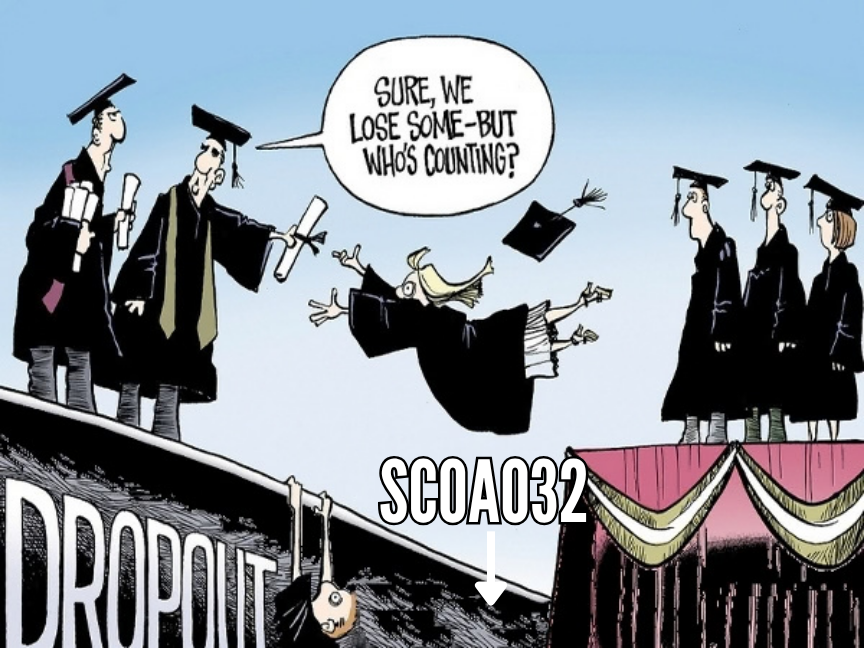

# The Big Picture

## Frame The Problem
Student dropout is a challenge in educational institutions, leading to wasted resources,
reduced institutional performance, and negative long term outcomes for the students themselves.
Identifying at-risk students early would allow institutions to intervene (through academic support,
counseling, or financial aid) before a student drops out. This project aims to build a machine learning
model that predicts whether a student is likely to drop out, based on academic, demographic, and
socio-economic features.

## Select A Model
- Train baseline models: Logistic Regression, Decision Tree 
- Train stronger models: Random Forest, Gradient Boosting (XGBoost/LightGBM)

## Select A Performance Measure
- Metrics: Accuracy, Precision, Recall, F1-score, ROC-AUC
- Confusion matrix 
- Feature importance analysis (to explain why the model predicts dropout)

## About The Dataset
This dataset simulates a realistic academic environment for 10,000 students and is designed for predicting student dropout. It includes demographic, behavioral, and academic performance features such as GPA, semester GPA, CGPA, study habits, attendance, stress index, parental education, and department.

Although synthetic, the data closely mimics real-world student distributions, including slight skewness in income and stress, missing values (~5%) in some features, and logical correlations between academic performance and dropout risk.

# Objectives

In this Notebook, we will complete the following tasks:
- Examine the dataset containing measurements.
- Visualize data to gain insights.
- Prepare the data for machine learning algorithms
- Select a model and train it
- Evaluate the performance of the model.
- Fine tune the model
- Maintain & monitor the system

## Dataset

This Notebook uses the student droput prediction set dataset on kaggle.

Provided with a CC0 license (see [Kaggle](https://www.kaggle.com/datasets/meharshanali/student-dropout-prediction-dataset) for more documentation.)

# Load Imports

In [598]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import plotly.express as px
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.feature_selection import RFE
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from scipy.stats import loguniform, uniform
import numpy as np
import statsmodels.api as sm



df = pd.read_csv("student_dropout_dataset_v3.csv", index_col=0)



# Explore the dataset

Plot some of the features against each other, including in 3D.


## Column Info

In [599]:
# column info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 1 to 10000
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    10000 non-null  float64
 1   Gender                 10000 non-null  str    
 2   Family_Income          9500 non-null   float64
 3   Internet_Access        10000 non-null  str    
 4   Study_Hours_per_Day    9500 non-null   float64
 5   Attendance_Rate        10000 non-null  float64
 6   Assignment_Delay_Days  10000 non-null  int64  
 7   Travel_Time_Minutes    10000 non-null  float64
 8   Part_Time_Job          10000 non-null  str    
 9   Scholarship            10000 non-null  str    
 10  Stress_Index           9500 non-null   float64
 11  GPA                    10000 non-null  float64
 12  Semester_GPA           10000 non-null  float64
 13  CGPA                   10000 non-null  float64
 14  Semester               10000 non-null  str    
 15  Department   

## Histogram

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Family_Income'}>,
        <Axes: title={'center': 'Study_Hours_per_Day'}>],
       [<Axes: title={'center': 'Attendance_Rate'}>,
        <Axes: title={'center': 'Assignment_Delay_Days'}>,
        <Axes: title={'center': 'Travel_Time_Minutes'}>],
       [<Axes: title={'center': 'Stress_Index'}>,
        <Axes: title={'center': 'GPA'}>,
        <Axes: title={'center': 'Semester_GPA'}>],
       [<Axes: title={'center': 'CGPA'}>,
        <Axes: title={'center': 'Dropout'}>, <Axes: >]], dtype=object)

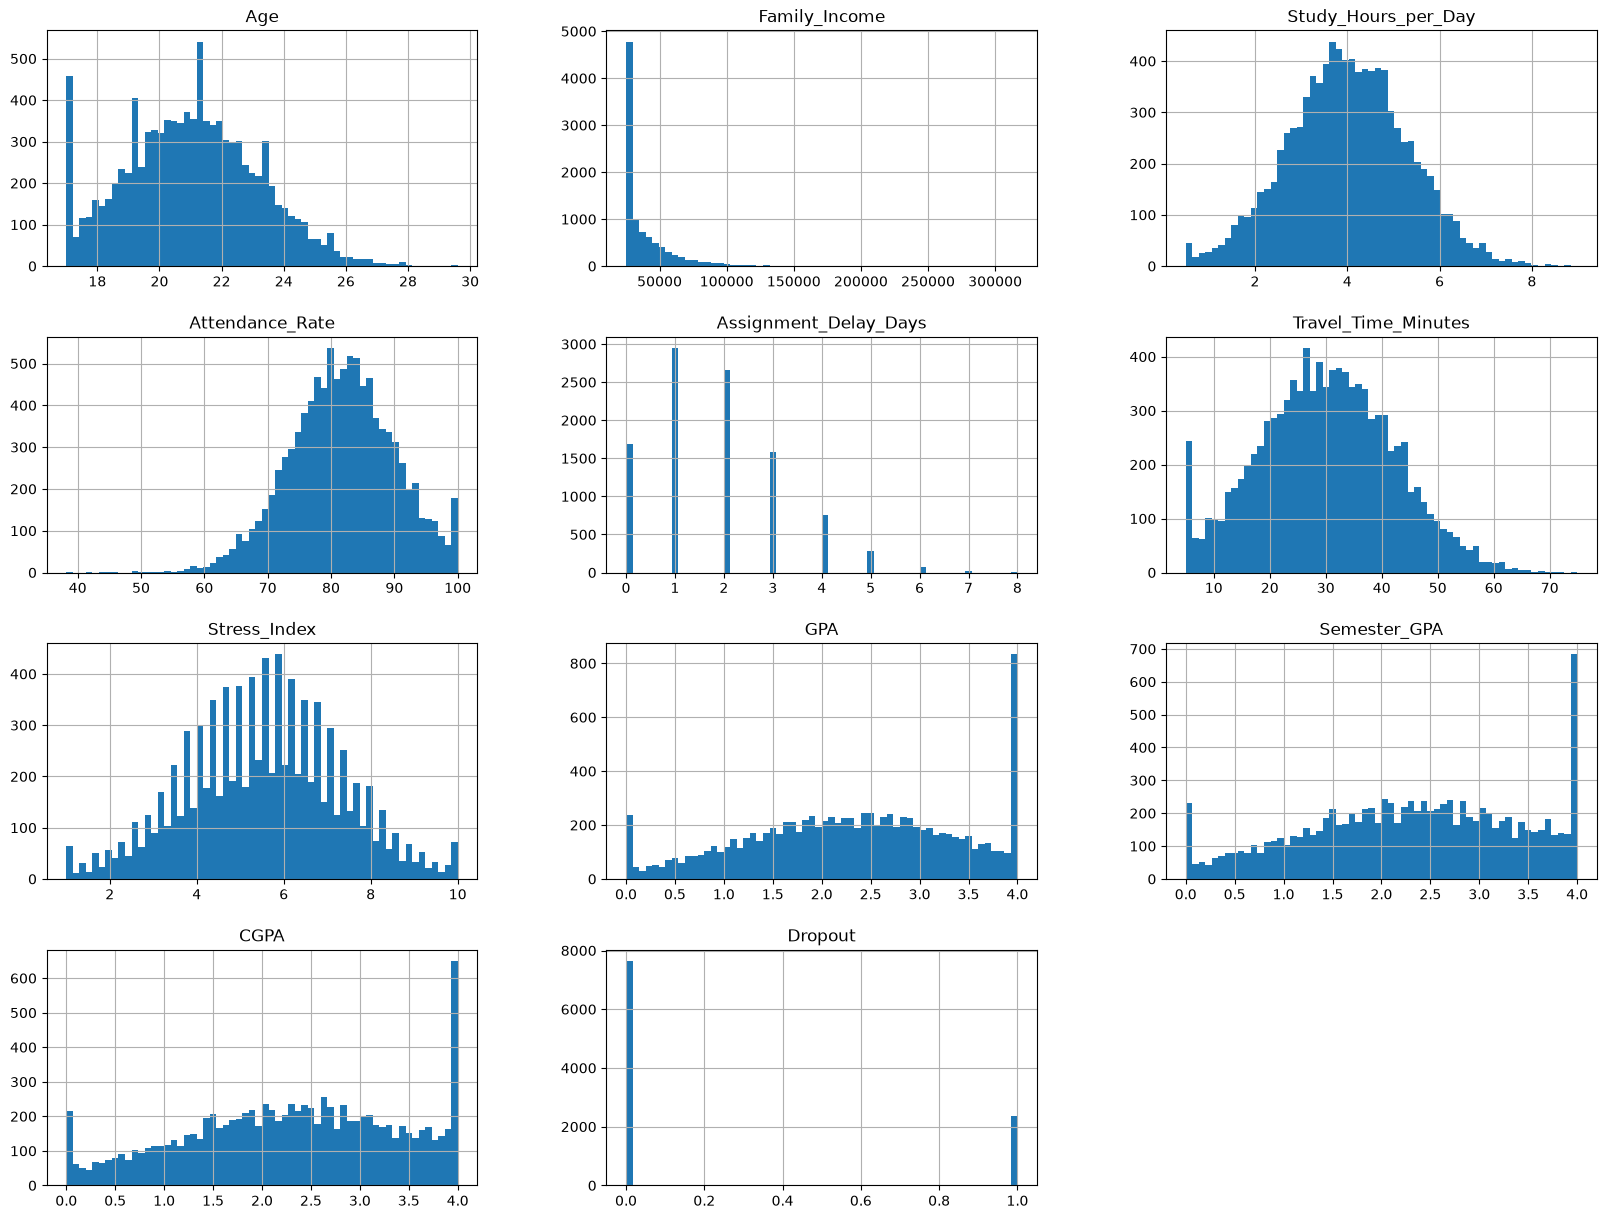

In [600]:
# column histogram
df.hist(bins=60, figsize=(20,15))

## Scatter Plot

In [601]:
y = df['Dropout']
X_full = df.drop(['Dropout'], axis=1)

# Color code by a drop out
color_col = 'Dropout'  # alternatives: 'Gender', 'Semester', 'Parental_Education'

for x_axis_data, y_axis_data in [
    ('Study_Hours_per_Day', 'GPA'),
    ('Attendance_Rate', 'CGPA'),
    ('Stress_Index', 'GPA'),
    ('Assignment_Delay_Days', 'Semester_GPA'),
    ('Travel_Time_Minutes', 'Attendance_Rate'),
]:
    px.scatter(
        df,
        x=x_axis_data,
        y=y_axis_data,
        color=color_col
    ).show()

## Looking For Correlations

In [602]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix["Dropout"].sort_values(ascending=True)

GPA                     -0.460352
Semester_GPA            -0.445396
CGPA                    -0.444807
Attendance_Rate         -0.163539
Study_Hours_per_Day     -0.089376
Family_Income           -0.011123
Age                      0.007585
Travel_Time_Minutes      0.028080
Assignment_Delay_Days    0.082327
Stress_Index             0.255648
Dropout                  1.000000
Name: Dropout, dtype: float64

# Set the random seeds

To make experiments reproducible, we set the seed of the random number generators. This means that the order in which the data is shuffled, the values of the random weight initializations, etc, will all be the same each time the notebook is run.

In [603]:
random_seed = 42

# Label and split data

To train the model, we'll arbritrarily assign the feature to X_full variable and target to y variable

In [604]:
X_train, X_valid, y_train, y_valid = train_test_split(X_full, y, test_size=0.2, random_state=random_seed)
X_valid, X_test, y_valid, y_test  = train_test_split(X_valid, y_valid, test_size=0.50, random_state=random_seed)

print(f"train: {X_train.shape}", f"valid: {X_valid.shape}", f"test: {X_test.shape}")

train: (8000, 17) valid: (1000, 17) test: (1000, 17)


# Clean Dataset

## Duplicates


In [605]:
df.duplicated().sum()

np.int64(0)

We can then randomize and partition the dataset into train, validation, and test splits, consisting of 80%, 10%, and 10% of the dataset respectively.

- Training data will be used to learn the model parameters
- Validation data is to evaluate different models
- Finally, test data to compute the final metrics for the model that performed best on the validation data.

## Outliers

In [607]:
def flag_outliers_zscore(df, cols, threshold=3):
    """Return boolean mask (rows) where ANY of `cols` has |z| > threshold."""
    mask = pd.Series(False, index=df.index)
    for col in cols:
        z = np.abs((df[col] - df[col].mean()) / df[col].std(ddof=0))
        mask |= (z > threshold)
    return mask

# Apply to numerical columns only (z-scores are meaningless on categoricals)
numerical_cols = [cname for cname in X_train.columns if X_train[cname].dtype in ['float64']]
outlier_mask = flag_outliers_zscore(X_train, numerical_cols, threshold=3)
print("Outliers flagged:", outlier_mask.sum())
print(f"({outlier_mask.mean()*100:.2f}% of rows)")

z_scores = (X_train[numerical_cols] - X_train[numerical_cols].mean()) \
           / X_train[numerical_cols].std(ddof=0)

per_col_outliers = (z_scores.abs() > 3).sum().sort_values(ascending=False)
print(per_col_outliers)

# Rows flagged
X_train_out = X_train[outlier_mask]
print(X_train_out[numerical_cols].describe())

# Which columns drive the flags?
for col in numerical_cols:
    n = (np.abs((X_train[col] - X_train[col].mean()) / X_train[col].std(ddof=0)) > 3).sum()
    if n > 0:
        print(f"{col}: {n} outliers")

Outliers flagged: 582
(7.27% of rows)
cat__Parental_Education_PhD            388
num__Family_Income                     153
num__Age                                19
num__Study_Hours_per_Day                15
num__Attendance_Rate                     9
num__Travel_Time_Minutes                 7
num__GPA                                 0
num__Semester_GPA                        0
num__CGPA                                0
cat__Gender_Female                       0
cat__Gender_Male                         0
cat__Internet_Access_No                  0
cat__Internet_Access_Yes                 0
num__Stress_Index                        0
cat__Part_Time_Job_No                    0
cat__Part_Time_Job_Yes                   0
cat__Scholarship_Yes                     0
cat__Scholarship_No                      0
cat__Semester_Year 2                     0
cat__Semester_Year 3                     0
cat__Semester_Year 4                     0
cat__Semester_Year 1                     0
cat__Department_

## Influential Outliers

In [608]:
X_with_const = sm.add_constant(X_train[numerical_cols])
model = sm.Logit(y_train, X_with_const).fit(disp=0)

influence = model.get_influence()
leverage = influence.hat_matrix_diag

# Rule of thumb: high leverage if h_ii > 2p/n  (p = #features, n = #samples)
n, p = X_with_const.shape
threshold = 2 * p / n
high_leverage = leverage > threshold
print(f"High-leverage points: {high_leverage.sum()} (threshold={threshold:.4f})")

ValueError: The indices for endog and exog are not aligned

## Preprocessing pipeline
Here we bundle preprocessing and steps so you can use the whole bundle as if it were a single step

- Missing Values: We used the mean for numeric values and mode for categorical variables
- Normalize Data: Data is normalized using Z-Score to avoid extremely low and high weights.
- Categorical Variables: Owe used one hot encoding.

In [ ]:
categorical_cols = [cname for cname in X_train.columns if X_train[cname].nunique() < 10 and X_train[cname].dtype == "string"]
numerical_cols = [cname for cname in X_train.columns if X_train[cname].dtype in ['float64']]

total_cols = categorical_cols + numerical_cols

# keep selected columns
X = X_full[total_cols].copy()

# Preprocessing for numerical data
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
])
# Preprocessing for categorical data
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Bundle preprocessing for numerical and categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
])

X_train_clean = preprocessor.fit_transform(X_train)
X_valid_clean = preprocessor.transform(X_valid)
X_test_clean = preprocessor.transform(X_test)

# Generate csv after cleaning
feature_names = preprocessor.get_feature_names_out()
X_train = pd.DataFrame(X_train_clean, columns=feature_names)
X_valid = pd.DataFrame(X_valid_clean, columns=feature_names)
X_test = pd.DataFrame(X_test_clean, columns=feature_names)

X_train.to_csv('after_cleaning.csv', index=False)
print(numerical_cols)
print(X_train.info())


## Feature Selection

In [ ]:
estimator = LogisticRegression(random_state=random_seed, class_weight='balanced', max_iter=1000)
selector = RFE(estimator, step=1)

X_train_ndarray = selector.fit_transform(X_train, y_train)
X_valid_ndarray = selector.fit_transform(X_valid, y_valid)
X_test_ndarray = selector.fit_transform(X_test, y_test)



# --- 1. Which features were selected ---
selected_mask = selector.support_               # boolean array, True = kept
selected_features = X_train.columns[selected_mask]

X_train = pd.DataFrame(X_train_ndarray, columns=selected_features, index=X_train.index)
X_valid = pd.DataFrame(X_valid_ndarray, columns=selected_features, index=X_valid.index)
X_test = pd.DataFrame(X_test_ndarray, columns=selected_features, index=X_test.index)



print("Selected features:", list(selected_features))
print("Number selected:", selected_mask.sum())

Selected features: ['num__Family_Income', 'num__Attendance_Rate', 'num__Travel_Time_Minutes', 'num__Stress_Index', 'num__GPA', 'num__Semester_GPA', 'cat__Gender_Male', 'cat__Internet_Access_No', 'cat__Internet_Access_Yes', 'cat__Semester_Year 3', 'cat__Department_Engineering', 'cat__Department_Science', 'cat__Parental_Education_Bachelor', 'cat__Parental_Education_High School', 'cat__Parental_Education_PhD']
Number selected: 15


# Model training


## Pipeline
Bundle preprocessing and modeling steps to use the whole bundle as if it were a single step

In [ ]:
model_1 = LogisticRegression(random_state=random_seed, class_weight='balanced')

# Bundle preprocessing and modeling code in a pipeline
my_pipeline = Pipeline(steps=[('model', model_1)])

# Preprocessing of training data, fit model 
my_pipeline.fit(X_train, y_train)
# preds = my_pipeline.predict(X_valid)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['num__Family_Income','num__Attendance_Rate','num__Travel_Time_Minutes', ...,'cat__Parental_Education_Bachelor', 'cat__Parental_Education_High School','cat__Parental_Education_PhD']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.

# Cross validation

In [ ]:
# Accuracy
acc = cross_val_score(my_pipeline, X_train, y_train, cv=5, scoring='accuracy')
print("Accuracy:", acc)
print("  Mean of Accuracy score:", acc.mean(), " Std of Accuracy Score:", acc.std())

# F1
f1 = cross_val_score(my_pipeline, X_train, y_train, cv=5, scoring='f1')
print("F1:", f1)
print("  Mean of F1 score:", f1.mean(), " Std of F1 score:", f1.std())

# ROC-AUC
auc = cross_val_score(my_pipeline, X_train, y_train, cv=5, scoring='roc_auc')
print("ROC-AUC:", auc)
print("  Mean of ROC-AUC:", auc.mean(), " Std of ROC-AUC:", auc.std())


Accuracy: [0.729375 0.72875  0.73375  0.7525   0.74    ]
  Mean of Accuracy score: 0.7368750000000001  Std of Accuracy Score: 0.008785641695402769
F1: [0.55498458 0.57367387 0.55717256 0.60557769 0.58730159]
  Mean of F1 score: 0.5757420575625446  Std of F1 score: 0.018993494187778338
ROC-AUC: [0.80503675 0.82168248 0.80159189 0.84040121 0.82863244]
  Mean of ROC-AUC: 0.8194689542296022  Std of ROC-AUC: 0.01452519544854988


# Fine Tune Model

In [ ]:


lr_param_dist = [
    {'C': loguniform(1e-2, 1e2),
     'penalty': ['l2'],
     'solver': ['lbfgs', 'liblinear']},
    {'C': loguniform(1e-2, 1e2),
     'penalty': ['l1'],
     'solver': ['liblinear', 'saga']},
    {'C': loguniform(1e-2, 1e2),
     'penalty': ['elasticnet'],
     'solver': ['saga'],
     'l1_ratio': uniform(0.0, 1.0)},
]

log_reg = LogisticRegression(
    random_state=random_seed,
    class_weight='balanced',
    max_iter=5000,
)

rnd_search_lr = RandomizedSearchCV(
    log_reg,
    lr_param_dist,
    n_iter=30,               # try 30 random combinations
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2,
    random_state=random_seed,
)
rnd_search_lr.fit(X_train, y_train)

print("Best params:", rnd_search_lr.best_params_)
print("Best score :", rnd_search_lr.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/home/mothibi/Worktree/drop-out-classification/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/mothibi/Worktree/drop-out-classification/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  w

[CV] END .C=2.5378155082656657, penalty=l2, solver=liblinear; total time=   0.3s
[CV] END ..C=2.440060709081755, penalty=l2, solver=liblinear; total time=   0.3s
[CV] END ..C=2.440060709081755, penalty=l2, solver=liblinear; total time=   0.4s
[CV] END ..C=2.440060709081755, penalty=l2, solver=liblinear; total time=   0.5s


/home/mothibi/Worktree/drop-out-classification/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/mothibi/Worktree/drop-out-classification/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  w

[CV] END C=15.352246941973492, l1_ratio=0.1834347898661638, penalty=elasticnet, solver=saga; total time=   0.6s
[CV] END ..C=2.440060709081755, penalty=l2, solver=liblinear; total time=   0.7s
[CV] END ..C=2.440060709081755, penalty=l2, solver=liblinear; total time=   0.7s
[CV] END C=0.025113061677390018, l1_ratio=0.45924889196586716, penalty=elasticnet, solver=saga; total time=   0.7s
[CV] END C=15.352246941973492, l1_ratio=0.1834347898661638, penalty=elasticnet, solver=saga; total time=   0.7s
[CV] END .C=2.5378155082656657, penalty=l2, solver=liblinear; total time=   0.1s
[CV] END .C=2.5378155082656657, penalty=l2, solver=liblinear; total time=   0.1s
[CV] END C=15.352246941973492, l1_ratio=0.1834347898661638, penalty=elasticnet, solver=saga; total time=   0.6s
[CV] END .C=2.5378155082656657, penalty=l2, solver=liblinear; total time=   0.1s
[CV] END C=0.025113061677390018, l1_ratio=0.45924889196586716, penalty=elasticnet, solver=saga; total time=   0.6s
[CV] END C=0.0251130616773900

...

/home/mothibi/Worktree/drop-out-classification/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/mothibi/Worktree/drop-out-classification/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  w

[CV] END C=20.651425578959262, l1_ratio=0.3567533266935893, penalty=elasticnet, solver=saga; total time=   0.2s
[CV] END C=20.651425578959262, l1_ratio=0.3567533266935893, penalty=elasticnet, solver=saga; total time=   0.2s
[CV] END .....C=0.0366181922039243, penalty=l2, solver=lbfgs; total time=   0.1s
[CV] END C=20.651425578959262, l1_ratio=0.3567533266935893, penalty=elasticnet, solver=saga; total time=   0.2s
[CV] END .....C=0.0366181922039243, penalty=l2, solver=lbfgs; total time=   0.1s
[CV] END ....C=0.01987021538542863, penalty=l2, solver=lbfgs; total time=   0.1s
[CV] END .....C=0.0366181922039243, penalty=l2, solver=lbfgs; total time=   0.1s
[CV] END ....C=0.01987021538542863, penalty=l2, solver=lbfgs; total time=   0.1s
[CV] END ....C=0.01987021538542863, penalty=l2, solver=lbfgs; total time=   0.1s
[CV] END ....C=0.01987021538542863, penalty=l2, solver=lbfgs; total time=   0.1s
[CV] END .C=12.273800987852969, penalty=l2, solver=liblinear; total time=   0.1s
[CV] END .C=12.2

/home/mothibi/Worktree/drop-out-classification/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/mothibi/Worktree/drop-out-classification/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  w

[CV] END .C=12.273800987852969, penalty=l2, solver=liblinear; total time=   0.1s
[CV] END .C=12.273800987852969, penalty=l2, solver=liblinear; total time=   0.1s
Best params: {'C': np.float64(0.1653693718282443), 'penalty': 'l1', 'solver': 'liblinear'}
Best score : 0.8195615788069158


/home/mothibi/Worktree/drop-out-classification/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/mothibi/Worktree/drop-out-classification/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


# Evaluate System On Test Set

In [ ]:
final_model = rnd_search_lr.best_estimator_
# X_test = preprocessor.transform(X_test)

# final_predictions = final_model.predict(X_test['selected_features'])
final_model.predict(X_test.head())

print(y_test)

Student_ID
4344    0
1795    0
709     1
3384    1
4535    1
       ..
9921    0
6124    0
7517    1
6747    0
2909    1
Name: Dropout, Length: 1000, dtype: int64
